<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke05-agentisk-ai/04_agentisk_ai_perspektiver.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 15-30 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig med mindre notebooken ber om det
- Data: syntetisk case/materiale
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [1]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# Agentisk AI: perspektiver for helse, forskning og tjenesteutvikling

## Læringsmål

| Etter notebooken bør du kunne | Hvorfor dette er viktig i helse og omsorg |
|---|---|
| Forklare hvorfor AI-agenter har blitt et sentralt tema i 2026. | Det gjør det lettere å skille mellom hype, reell nytte og faktiske begrensninger. |
| Drøfte hvor agentiske systemer kan få betydning i klinikk, forskning og helse- og omsorgstjenester. | Teknologien er mest relevant når den kobles til konkrete arbeidsprosesser og faglige behov. |
| Beskrive forskjellen mellom agent-koordinering og trygg utførelse i virkelige systemer. | Mange løsninger ser like ut på overflaten, men løser ulike deler av problemet. |
| Reflektere over når lokale LLM-er og lokale agenter kan være spesielt aktuelle. | Sensitive data, personvern og lokal kontroll kan være avgjørende i helsefaglige sammenhenger. |
| Vurdere hvorfor menneskelig ansvar, logging og styring blir viktigere jo mer autonome systemene blir. | I helse er kontroll, sporbarhet og faglig kvalitetssikring helt sentralt. |

<br>

> **Merk:** Dette er pedagogisk materiale. Eksemplene er laget for læring og refleksjon, ikke for klinisk beslutningsstøtte.

Denne notebooken avslutter uke 05 ved å løfte blikket fra konkrete demoer til mer overordnede spørsmål: Hvorfor er agentisk AI blitt så mye omtalt, hvor kan slike systemer få betydning i helse, og hvilke grenser bør vi være tydelige på allerede nå?

I 2026 omtales AI-agenter ofte som et mulig neste steg etter rene chatløsninger. Det skyldes at språkmodeller i økende grad brukes i systemer som kan planlegge, bruke verktøy, samarbeide i roller og følge opp oppgaver over flere steg. Nettopp derfor blir det viktig å diskutere ikke bare hva som er teknisk mulig, men også hva som er faglig forsvarlig, organisatorisk klokt og praktisk gjennomførbart i helse, forskning og tjenesteutvikling.


## Hvorfor er AI-agenter så mye omtalt nå?

En viktig grunn er at oppmerksomheten i AI-feltet har flyttet seg fra enkeltstående svar til systemer som kan organisere arbeid. Når en språkmodell kombineres med verktøy, hukommelse, oppslag og flertrinnslogikk, får vi noe som ligner mer på en arbeidsflyt enn på en vanlig chatbot.

Dette gjør agentisk AI interessant fordi mange oppgaver i helse og forskning faktisk er oppgaver i flere steg. Det kan for eksempel handle om å:

- hente inn relevant informasjon
- vurdere hva som mangler
- fordele arbeid mellom roller eller deloppgaver
- lage et strukturert forslag som senere vurderes av et menneske

Samtidig er det viktig å være nøktern. At AI-agenter er mye omtalt betyr ikke at feltet er modent i alle sammenhenger. Mange løsninger ser imponerende ut i demoform, men blir langt vanskeligere å validere når de skal brukes i virkelige arbeidsprosesser med ansvar, personvern og konsekvenser for pasienter eller tjenester.


## Hvor kan agentisk AI få betydning i helse?

Det er nyttig å skille mellom minst tre områder der agentiske systemer kan bli relevante.

**I klinisk praksis** kan slike systemer tenkes brukt til oppsummering, koordinering, strukturering av informasjon, oppslag i prosedyrer og støtte i administrative eller kommunikative deler av pasientforløp. Her er det ofte tryggest å starte med lav- og moderat-risiko oppgaver.

**I biomedisinsk forskning** kan agentiske systemer bli nyttige for litteratursøk, sammenstilling av funn, støtte i protokollarbeid, strukturering av dataflyt og utkast til analyse- eller rapporteringsarbeid. Her kan gevinsten ligge i å avlaste tidskrevende kunnskapsarbeid.

**I helse- og omsorgstjenesten** kan de få betydning i samhandling, planlegging, oversikt, dokumentflyt og koordinering mellom roller og nivåer. Nettopp her kan agentiske systemer bli interessante fordi oppgavene ofte er komplekse, men ikke nødvendigvis direkte kliniske beslutninger.

Et gjennomgående poeng er at den første reelle nytten ofte kommer i koordinering og kunnskapsarbeid, ikke i autonome beslutninger om diagnose eller behandling.


## Fra agent-koordinering til trygg utførelse

Det er lett å snakke om alle slike systemer som om de gjør det samme, men det gjør de ikke. Noen rammeverk hjelper flere agenter å samarbeide og fordele roller. Andre systemer er mer opptatt av hvordan handlinger faktisk utføres trygt, logges, kan gjentas og kan kontrolleres i virkelige omgivelser.

En nyttig måte å tenke på er derfor å skille mellom:

- **koordinering av intelligens**: hvem resonnerer om hva, og hvordan deloppgaver henger sammen
- **styring av utførelse**: hva systemet faktisk får lov til å gjøre i virkelige systemer, med logging, kontroll og tydelige grenser

Dette skillet diskuteres også i industrinære tekster som [OpenClaw vs. CrewAI](https://www.hireoverseas.com/blogs/openclaw-vs-crewai), der poenget nettopp er at agent-samarbeid og trygg operativ utførelse ikke er det samme laget i arkitekturen.

I helse er dette et særlig viktig poeng. Det holder ikke at et system virker smart. Det må også være mulig å forstå hva det gjorde, hvorfor det gjorde det, og hvor menneskelig kontroll må komme inn.


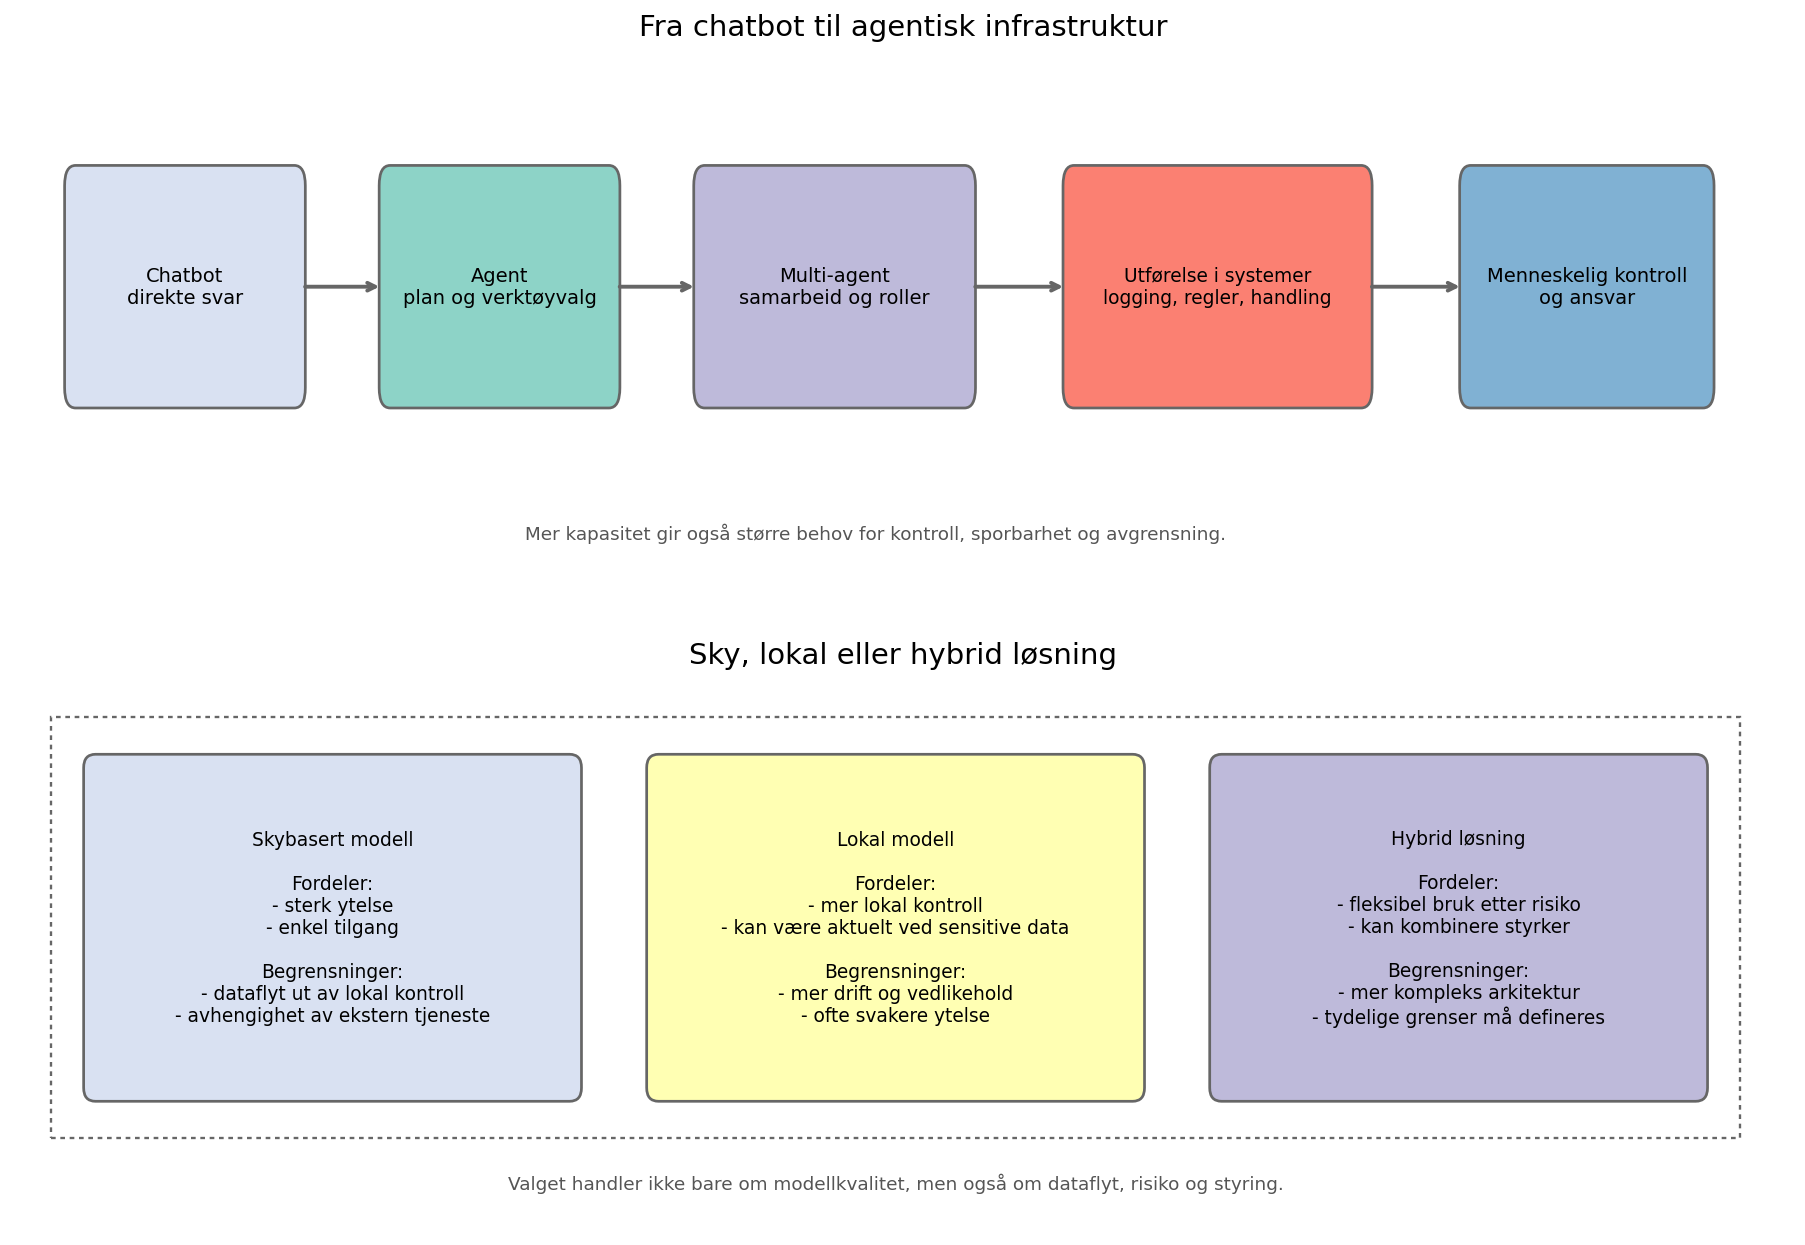

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle


plt.rcParams["figure.dpi"] = 140

PALETT = {
    "chatbot": "#d9e1f2",
    "agent": "#8dd3c7",
    "multi": "#bebada",
    "execution": "#fb8072",
    "control": "#80b1d3",
    "local": "#ffffb3",
}
EDGE = "#666666"
TEXT = "#555555"


def add_box(ax, x, y, w, h, text, facecolor, fontsize=10, linestyle="solid"):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.4,
        edgecolor=EDGE,
        facecolor=facecolor,
        linestyle=linestyle,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Figur 1
ax = axes[0]
ax.set_title("Fra chatbot til agentisk infrastruktur", fontsize=15)

add_box(ax, 0.4, 1.0, 1.7, 0.9, "Chatbot\ndirekte svar", PALETT["chatbot"])
add_box(ax, 2.7, 1.0, 1.7, 0.9, "Agent\nplan og verktøyvalg", PALETT["agent"])
add_box(ax, 5.0, 1.0, 2.0, 0.9, "Multi-agent\nsamarbeid og roller", PALETT["multi"])
add_box(ax, 7.7, 1.0, 2.2, 0.9, "Utførelse i systemer\nlogging, regler, handling", PALETT["execution"], fontsize=9.6)
add_box(ax, 10.6, 1.0, 1.8, 0.9, "Menneskelig kontroll\nog ansvar", PALETT["control"])

for x1, x2 in [(2.1, 2.7), (4.4, 5.0), (7.0, 7.7), (9.9, 10.6)]:
    ax.annotate("", xy=(x2, 1.45), xytext=(x1, 1.45), arrowprops=dict(arrowstyle="->", lw=2, color=EDGE))

ax.text(6.3, 0.45, "Mer kapasitet gir også større behov for kontroll, sporbarhet og avgrensning.", ha="center", fontsize=9.5, color=TEXT)
ax.set_xlim(0, 13)
ax.set_ylim(0.2, 2.4)
ax.axis("off")

# Figur 2
ax = axes[1]
ax.set_title("Sky, lokal eller hybrid løsning", fontsize=15)

add_box(ax, 0.5, 0.9, 3.3, 2.0, "Skybasert modell\n\nFordeler:\n- sterk ytelse\n- enkel tilgang\n\nBegrensninger:\n- dataflyt ut av lokal kontroll\n- avhengighet av ekstern tjeneste", PALETT["chatbot"], fontsize=9.6)
add_box(ax, 4.3, 0.9, 3.3, 2.0, "Lokal modell\n\nFordeler:\n- mer lokal kontroll\n- kan være aktuelt ved sensitive data\n\nBegrensninger:\n- mer drift og vedlikehold\n- ofte svakere ytelse", PALETT["local"], fontsize=9.6)
add_box(ax, 8.1, 0.9, 3.3, 2.0, "Hybrid løsning\n\nFordeler:\n- fleksibel bruk etter risiko\n- kan kombinere styrker\n\nBegrensninger:\n- mer kompleks arkitektur\n- tydelige grenser må defineres", PALETT["multi"], fontsize=9.6)

boundary = Rectangle((0.25, 0.65), 11.4, 2.5, fill=False, linestyle=(0, (2, 2)), linewidth=1.2, edgecolor=EDGE)
ax.add_patch(boundary)
ax.text(5.95, 0.35, "Valget handler ikke bare om modellkvalitet, men også om dataflyt, risiko og styring.", ha="center", fontsize=9.5, color=TEXT)
ax.set_xlim(0, 12)
ax.set_ylim(0.1, 3.4)
ax.axis("off")

plt.tight_layout(h_pad=2.0)
plt.show()


<details>
<summary><strong>Diskuter</strong></summary>

Hva virker mest risikabelt i helse: et system som resonnerer fritt, eller et system som handler direkte i virkelige systemer som journal, timebok eller meldingsflyt?

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at begge deler kan være risikable, men at risikoen ofte øker kraftig når et system ikke bare foreslår noe, men faktisk utfører handlinger i virkelige systemer. Derfor er skillet mellom resonnering og utførelse spesielt viktig i helse.

</details>

<br>

> **Faglig poeng:** I helse må intelligent koordinering alltid kombineres med tydelige grenser for hva systemet får lov til å gjøre.


## Lokale LLM-er og lokale agenter

Diskusjonen om lokale språkmodeller og lokale agenter blir særlig relevant i helse fordi mange data er sensitive. Når systemer arbeider med pasientopplysninger, interne dokumenter eller forskningsdata med strenge krav til kontroll, kan det være gode grunner til å vurdere løsninger som kjøres lokalt eller i strengt avgrensede miljøer.

Lokale løsninger kan være aktuelle når man ønsker:

- bedre kontroll over hvor data befinner seg
- tydeligere grenser for hvem som har tilgang til informasjonen
- mulighet for intern drift i sikrede miljøer
- mindre avhengighet av eksterne API-er i enkelte arbeidsflyter

Samtidig er ikke lokale modeller automatisk bedre. De kan være svakere på noen oppgaver, kreve mer teknisk drift og flytte mer ansvar for sikkerhet, vedlikehold og evaluering over på den som bruker dem. Nettopp derfor bør spørsmålet ikke bare være om en modell er lokal eller skybasert, men om løsningen passer risikoen, dataene og formålet.


<details>
<summary><strong>Tenk selv</strong></summary>

I hvilke typer helsefaglige oppgaver ville du først vurdert en lokal modell eller en lokal agent, og i hvilke typer oppgaver ville en skybasert løsning vært lettere å forsvare?

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at lokale modeller kan være særlig aktuelle ved oppgaver som involverer sensitive data, interne dokumenter eller strenge krav til lokal kontroll. Skybaserte løsninger kan være lettere å bruke der data er mindre sensitive, eller der man trenger høy modellkvalitet i klart avgrensede og godt kontrollerte arbeidsflyter.

</details>

<br>

> **Faglig poeng:** Valg av modell er ikke bare et spørsmål om ytelse, men også om dataflyt, ansvar og kontekst.


## Hva kan dette bety for fremtidig medisinsk praksis, forskning og tjenesteutvikling?

Hvis agentiske systemer blir mer modne, kan de få betydning på flere nivåer samtidig.

**For medisinsk praksis** kan de bidra til mer strukturert informasjonsflyt, bedre oppsummering og støtte i flertrinnsoppgaver rundt dokumentasjon, koordinering og kommunikasjon. Det betyr ikke at de bør overta kliniske vurderinger, men at de kan bli mer relevante som arbeidsstøtte.

**For biomedisinsk forskning** kan de bidra til å organisere litteratur, foreslå deloppgaver, strukturere kunnskapsarbeid og støtte framdrift i prosjekter. Her kan gevinsten bli stor fordi mye forskningsarbeid faktisk handler om oversikt, sammenstilling og iterasjon.

**For helse- og omsorgstjenester** kan de bli nyttige i planlegging, samhandling, oversikt og bedre kobling mellom ulike informasjonskilder. Men jo nærmere slike systemer kommer reelle tjenester, desto viktigere blir også logging, rolleavklaring, tilgangskontroll og menneskelig sluttansvar.

Den kanskje viktigste endringen er derfor ikke bare at AI kan svare bedre, men at AI i økende grad kan inngå i måten arbeid organiseres på. Det er nettopp dette som gjør agentisk AI både lovende og krevende.


## En nøktern anbefaling for helsefeltet nå

Hvis helsefeltet skal utforske agentisk AI på en klok måte, kan det være nyttig å holde fast ved noen enkle prinsipper:

- start med lav- og moderat-risiko oppgaver
- skill tydelig mellom forslag og handling
- bygg inn logging, avgrensning og menneskelig kontroll fra starten av
- vurder lokale eller hybride løsninger når dataene er sensitive
- bruk agentiske systemer der de faktisk gir merverdi, ikke bare fordi teknologien er ny

En slik tilnærming gir rom for forsiktig optimisme. Agentisk AI kan bli viktig i helse, men bare dersom den kobles til reelle behov, tydelige grenser og ansvarlige arbeidsmåter.


## Refleksjon

- Hvilke typer helsefaglige oppgaver virker mest egnet for agentisk AI i nær fremtid?
- Hvor går grensen mellom nyttig arbeidsstøtte og for stor autonomi?
- Når bør lokale modeller vurderes av hensyn til sensitive data?
- Hvilke krav til logging, styring og dokumentasjon bør stilles før slike systemer brukes mer i praksis?

## Videre lesning

- [MIT AI Agent Index 2025](https://aiagentindex.mit.edu/2025/)
- [OpenAI: A practical guide to building AI agents](https://openai.com/business/guides-and-resources/a-practical-guide-to-building-ai-agents)
- [Anthropic: Building Effective AI Agents](https://www.anthropic.com/index/building-effective-agents)
- [npj Digital Medicine: The role of agentic artificial intelligence in healthcare: a scoping review](https://www.nature.com/articles/s41746-026-02517-5)
- [PLOS One: Artificial intelligence agents in healthcare research: A scoping review](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0342182)
- [Hire Overseas: OpenClaw vs. CrewAI](https://www.hireoverseas.com/blogs/openclaw-vs-crewai)
